# To-Do:
- try all classes attempt
    - need to tweak directory manipulation scripts
- Custom CNN
    - 90 class subset

In [35]:
import tensorflow as tf
import keras
from keras.saving import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers,models
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)
import reload_data2
from google.colab import drive
import umap
from sklearn.manifold import TSNE

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/Handwriting_Metadata_clean.csv")
df=df.sort_values(by="wid").reset_index(drop=True)
df.head(5)

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


##### Divide ids into 4 sections for easy upload

In [ ]:
df.shape[0]

466

In [ ]:
df.shape[0]//4

116

In [ ]:
df.shape[0]%4

2

In [ ]:
df.wid.unique()[115]

np.int64(198)

In [ ]:
115+115

230

In [ ]:
df.wid.unique()[230]

np.int64(405)

In [ ]:
230+115

345

In [ ]:
df.wid.unique()[345]

np.int64(559)

In [ ]:
345+115

460

In [ ]:
df.wid.unique()[-1]

np.int64(720)

## Modify Directory structure

### Dump all images

In [4]:
zips=list()
for path in os.listdir("/content/drive/MyDrive/CSAFE_zips"):
    if ".zip" in path:
        zips.append(path)

zips

['CSAFE_All_Images_3.zip',
 'CSAFE_All_Images_4.zip',
 'CSAFE_All_Images_1.zip',
 'CSAFE_All_Images_2.zip']

In [5]:
drive_dir="/content/drive/MyDrive/CSAFE_zips"

In [6]:
data_dir = "/content/Data"
os.mkdir(data_dir)

In [7]:
%%time
try:
    shutil.rmtree(data_dir)
    os.mkdir(data_dir)
except:
    pass


for z in zips:
    print(f"Unzipping: {z}")
    try:
        reload_data2.unzip(f"{drive_dir}/{z}",data_dir)
    except zipfile.BadZipFile:
        print(f"ERROR: {z}")

Unzipping: CSAFE_All_Images_3.zip
Unzipping: CSAFE_All_Images_4.zip
Unzipping: CSAFE_All_Images_1.zip
Unzipping: CSAFE_All_Images_2.zip
CPU times: user 17 s, sys: 5.56 s, total: 22.6 s
Wall time: 1min 59s


#### Organize unzipped files

In [ ]:
w_ids = reload_data2.w_ids475

In [ ]:
len(w_ids)

475

In [ ]:
reload_data2.organize_unzipped_files(data_dir)

In [ ]:
def stratify_split_alt(source_dir, split=(15, 6, 6),writers_list=w_ids):
    """Re-organizes images in writer folders into train/val/test folders with writer sub-directories."""
    train_folder = os.path.join(source_dir, "train")
    val_folder = os.path.join(source_dir, "val")
    test_folder = os.path.join(source_dir, "test")

    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(val_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)

    for writer in writers_list:
        writer_path = os.path.join(source_dir, writer)
        if not os.path.exists(writer_path):
            print(f"⚠️ Writer directory not found: {writer_path}")
            continue

        writer_images = [f for f in os.listdir(writer_path) if f.endswith(".png")]
        if not writer_images:
            continue

        random.shuffle(writer_images)
        tr, va, te = split
        train_set = writer_images[:tr]
        val_set = writer_images[tr:tr+va]
        test_set = writer_images[tr+va:]

        for subset, folder, image_set in zip(
            ["train", "val", "test"],
            [train_folder, val_folder, test_folder],
            [train_set, val_set, test_set],
        ):
            destination = os.path.join(folder, writer)
            os.makedirs(destination, exist_ok=True)

            for image in image_set:
                src = os.path.join(writer_path, image)
                if os.path.exists(src):
                    shutil.move(src, destination)
                else:
                    print(f"⚠️ File not found, skipping: {src}")

stratify_split_alt(data_dir)

In [ ]:
for writer in w_ids:
    try:
        os.rmdir(f"{data_dir}/{writer}")
    except:
        print(f"ERROR: {writer}")

In [ ]:
print(len(os.listdir(f"{data_dir}/train")),
      len(os.listdir(f"{data_dir}/test")),
      len(os.listdir(f"{data_dir}/val")),sep="\n")

475
475
475


In [ ]:
os.listdir(data_dir)

['test', 'CSAFE_Handwriting_Info.csv', 'train', 'val']

    disparity between given metadata and true labels

In [ ]:
ls Data/test

w0001/  w0075/  w0150/  w0254/  w0342/  w0410/  w0472/  w0535/  w0598/  w0665/
w0002/  w0076/  w0151/  w0255/  w0344/  w0411/  w0473/  w0536/  w0599/  w0666/
w0003/  w0077/  w0152/  w0260/  w0345/  w0412/  w0474/  w0537/  w0600/  w0667/
w0004/  w0078/  w0153/  w0261/  w0348/  w0413/  w0475/  w0538/  w0601/  w0668/
w0005/  w0080/  w0154/  w0262/  w0350/  w0414/  w0476/  w0541/  w0602/  w0669/
w0006/  w0082/  w0155/  w0263/  w0351/  w0415/  w0477/  w0542/  w0604/  w0670/
w0009/  w0083/  w0156/  w0264/  w0352/  w0416/  w0478/  w0543/  w0605/  w0671/
w0010/  w0085/  w0157/  w0270/  w0353/  w0417/  w0479/  w0546/  w0606/  w0673/
w0011/  w0086/  w0160/  w0271/  w0354/  w0418/  w0480/  w0547/  w0611/  w0674/
w0012/  w0087/  w0162/  w0276/  w0355/  w0419/  w0481/  w0548/  w0612/  w0675/
w0013/  w0088/  w0175/  w0277/  w0356/  w0420/  w0483/  w0549/  w0613/  w0677/
w0015/  w0089/  w0177/  w0279/  w0357/  w0422/  w0484/  w0550/  w0615/  w0678/
w0016/  w0090/  w0180/  w0280/  w0359/  w0424/  w048

In [ ]:
ls Data/train/w0249

w0249_s01_pLND_r02.png  w0249_s02_pLND_r01.png  w0249_s02_pWOZ_r02.png
w0249_s01_pPHR_r01.png  w0249_s02_pLND_r03.png  w0249_s03_pLND_r01.png
w0249_s01_pPHR_r02.png  w0249_s02_pPHR_r01.png  w0249_s03_pLND_r02.png
w0249_s01_pWOZ_r01.png  w0249_s02_pPHR_r02.png  w0249_s03_pLND_r03.png
w0249_s01_pWOZ_r03.png  w0249_s02_pWOZ_r01.png  w0249_s03_pWOZ_r03.png


# Modelling

## train/test/val split

In [ ]:
help(reload_data2)

Help on module reload_data2:

NAME
    reload_data2

FUNCTIONS
    apply_augmentations()
        Apply `data_augmentation` to the training images.

    data_augmentation(images)
        Function for testing augmentations with test_augmentations(), not meant for use

        For applying augmentations, use: apply_augmentations()

    del_old_writer_directories(source_dir)
        Deletes original writer-organized directories (for use after creating train/val/test directories with stratify_split())

    full_unzip_and_stratify(path_of_zipfile, source_dir, IMAGE_SIZE=(384, 384), BATCH_SIZE=18)
        Starts with zipped file, divides unzipped images by author, splits sorted images into train/val/test images,
        creates & returns train/val/test datatsets

    organize_unzipped_files(source_dir)
        Organizes raw unzipped files into writer folders

    stratify_split(source_dir, split=[15, 6, 6])
        Re-organizes images in writer folders into train/val/test folders with writer 

### Copied from Baseline2 (best performing model)

In [ ]:
IMAGE_SIZE = (384,384)#(442,442)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 475

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    labels='inferred',
    color_mode='rgb',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    )
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/val",
    labels='inferred',
    color_mode='rgb',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    )
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/test",
    labels='inferred',
    color_mode='rgb',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    )

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)
test_ds = test_ds.prefetch(tf_data.AUTOTUNE)

Found 7125 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.


In [ ]:
def make_transfer_model(input_shape, num_classes, name):
    backbone = base_model

    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.25)(x) #changed to 30% dropout
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=name)

base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

model = make_transfer_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                            name="mobilenet_allclass")

/tmp/ipykernel_2924/3663097199.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.summary()

Model: "mobilenet_allclass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 475)            │       608,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,459 (10.93 MB)

 Trainable params: 608,475 (2.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## epochs

In [ ]:
%%time

epochs = 100

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("MobileNetV2_allclass.keras")

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 130s 826ms/step - acc: 0.0114 - loss: 6.4385 - top3_acc: 0.0254 - val_acc: 0.0470 - val_loss: 5.1932 - val_top3_acc: 0.1193
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - acc: 0.0803 - loss: 5.0046 - top3_acc: 0.1569 - val_acc: 0.1386 - val_loss: 4.6147 - val_top3_acc: 0.2491
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - acc: 0.1559 - loss: 4.4105 - top3_acc: 0.2738 - val_acc: 0.2014 - val_loss: 4.1978 - val_top3_acc: 0.3509
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 311ms/step - acc: 0.2361 - loss: 3.9526 - top3_acc: 0.3826 - val_acc: 0.2425 - val_loss: 3.9009 - val_top3_acc: 0.4211
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - acc: 0.2998 - loss: 3.6004 - top3_acc: 0.4681 - val_acc: 0.3053 - val_loss: 3.6397 - val_top3_acc: 0.4793
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 308ms/step - acc: 0.3652 - loss: 3.3151 - top3_acc: 0.5240 - val_acc: 0.3418 - val_loss: 3.4269 - val_top3_acc: 0.5260
Epoch 7/100
112

In [ ]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("AllClass_lossacc.csv")

### Visualization

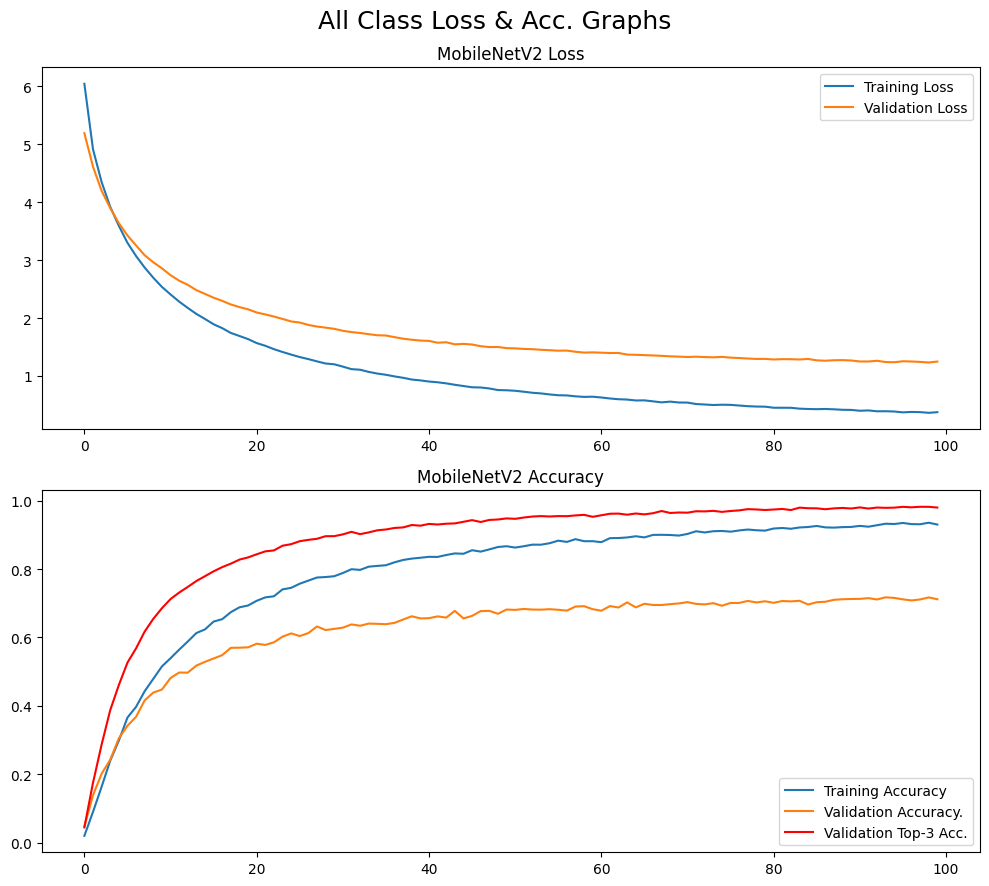

In [ ]:
plt.figure(figsize=(10,8))
plt.suptitle("All Class Loss & Acc. Graphs",size=18)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
history = pd.read_csv("/content/AllClass_lossacc.csv")
history.head()

,Unnamed: 0,acc,loss,top3_acc,val_acc,val_loss,val_top3_acc
0,0,0.019930,6.046656,0.044632,0.047018,5.193250,0.119298
1,1,0.089825,4.916351,0.174877,0.138596,4.614721,0.249123
2,2,0.163228,4.349504,0.286596,0.201404,4.197822,0.350877
3,3,0.239719,3.921549,0.387509,0.242456,3.900949,0.421053
4,4,0.298386,3.593375,0.460912,0.305263,3.639660,0.479298


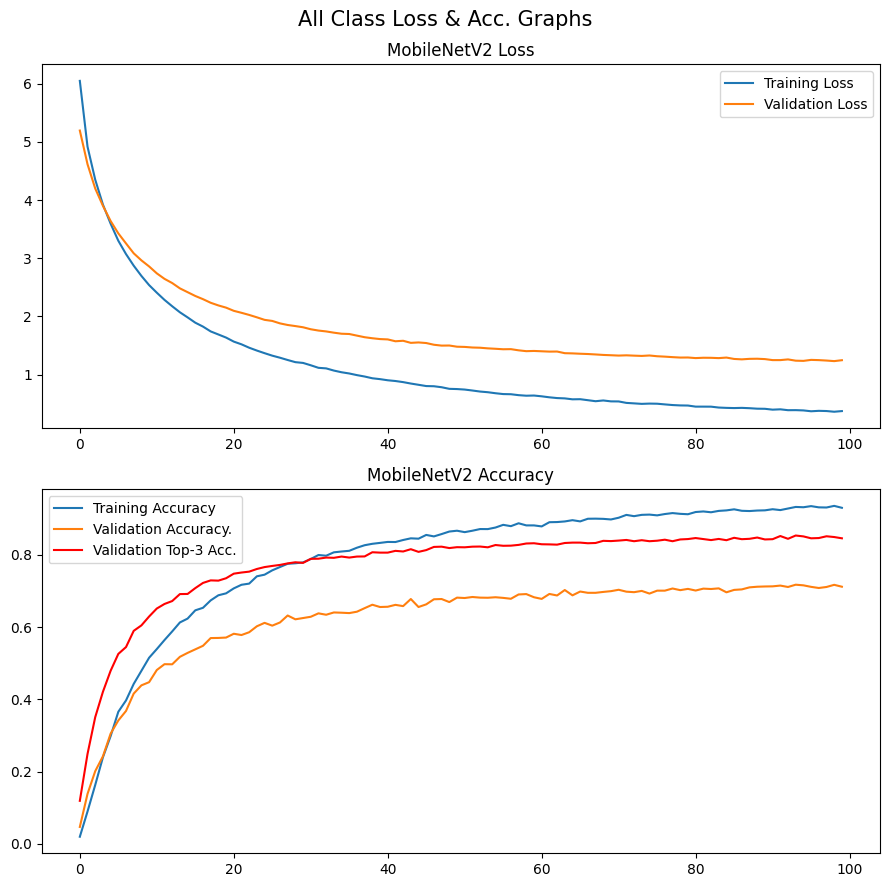

In [ ]:
#previous graph is incorrect
plt.figure(figsize=(9,9))
plt.suptitle("All Class Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history["loss"])),history["loss"],label="Training Loss")
plt.plot(range(len(history["val_loss"])),history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history["acc"])),history["acc"],label="Training Accuracy")
plt.plot(range(len(history["val_acc"])),history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history["val_top3_acc"])),history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

    after ~70 epochs doesn't seem significant

### Test Set

In [ ]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - acc: 0.7224 - loss: 1.1839 - top3_acc: 0.8616
{'acc': 0.7200000286102295, 'loss': 1.1924022436141968, 'top3_acc': 0.8575438857078552}


# Custom CNN

## tran/val/test split

In [36]:
IMAGE_SIZE = (384,384)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 475

In [9]:
reload_data2.organize_unzipped_files(data_dir)

In [10]:
reload_data2.stratify_split_alt(data_dir,475)

Using 475 class labels


In [19]:
new_data_dir = "New_Data"
os.mkdir(new_data_dir)

In [20]:
%%time
import os
import PIL
from PIL import Image
from tqdm import tqdm
def process_dataset(input_root, output_root, target_size=None):
    """
    input_root: 'path/to/original_data'
    output_root: 'path/to/padded_data'
    target_size: optional tuple like (384, 384) to resize after padding
    """
    for class_name in os.listdir(input_root):
        for x in ["train","val","test"]:
            set_path = os.path.join(input_root, x)
            class_path = os.path.join(set_path, class_name)
            if not os.path.isdir(class_path):
                continue

            # Create corresponding class folder in output directory
            output_class_path = os.path.join(output_root, class_name)
            os.makedirs(output_class_path, exist_ok=True)

            print(f"Processing class: {class_name}")

            for img_name in tqdm(os.listdir(class_path)):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)

                    # 1. Open and pad
                    with Image.open(img_path) as img:
                        img = img.convert("RGB") # Ensure no Alpha channels
                        w, h = img.size
                        max_dim = max(w, h)

                        # Create white canvas
                        squared_img = Image.new("RGB", (max_dim, max_dim), (255, 255, 255))

                        # Paste (using 0,0 for bottom-padding as requested)
                        squared_img.paste(img, (0, 0))

                        # 2. Optional: Resize immediately to 384x384
                        if target_size:
                            squared_img = squared_img.resize(target_size, Image.LANCZOS)

                        # 3. Save to the new directory
                        squared_img.save(os.path.join(output_class_path, img_name))

process_dataset(data_dir, new_data_dir, target_size=(384, 384))

Processing class: w0186


100%|██████████| 15/15 [00:02<00:00,  5.45it/s]


Processing class: w0186


100%|██████████| 6/6 [00:01<00:00,  5.46it/s]


Processing class: w0186


...

Processing class: w0191


100%|██████████| 6/6 [00:01<00:00,  5.57it/s]


Processing class: w0191


100%|██████████| 6/6 [00:01<00:00,  5.10it/s]

CPU times: user 30min 10s, sys: 5min 55s, total: 36min 6s
Wall time: 36min 1s


In [37]:
reload_data2.stratify_split_alt(new_data_dir,475)

Using 475 class labels


In [38]:
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(new_data_dir,IMAGE_SIZE,BATCH_SIZE)

Found 7125 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.


In [23]:
! zip -rq /content/drive/MyDrive/CSAFE_zips/Custom_test.zip /content/New_Data/test

In [24]:
drive_dir="/content/drive/MyDrive/CSAFE_zips"

## epochs

In [25]:
model = models.Sequential([

    layers.Input(shape=INPUT_SHAPE),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation=None)
    ],name="custom")

model.summary()

Model: "custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 384, 384, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 384, 384, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 192, 192, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 192, 192, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 192, 192, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 96, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 475)            │       122,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,203 (2.21 MB)

 Trainable params: 577,243 (2.20 MB)

 Non-trainable params: 960 (3.75 KB)

In [26]:
%%time

epochs = 80

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), ###make sure is true
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_acc',   # Metric to monitor (e.g., validation loss)
    patience=7,           # Number of epochs with no improvement after which training will be stopped
    min_delta=0.001,      # Minimum change to qualify as an improvement
    mode='max',
    verbose=1,            # Log messages when the callback acts
    restore_best_weights=True # Restores the best model weights
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds,
    callbacks=[early_stopping])

model.save(f"{drive_dir}/Custom_allclass.keras")

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 24s 149ms/step - acc: 0.0038 - loss: 6.1202 - top3_acc: 0.0100 - val_acc: 0.0018 - val_loss: 10.8332 - val_top3_acc: 0.0063
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - acc: 0.0121 - loss: 5.6033 - top3_acc: 0.0371 - val_acc: 0.0021 - val_loss: 13.3089 - val_top3_acc: 0.0063
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - acc: 0.0355 - loss: 4.9531 - top3_acc: 0.0884 - val_acc: 0.0021 - val_loss: 23.7189 - val_top3_acc: 0.0074
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - acc: 0.0714 - loss: 4.3781 - top3_acc: 0.1672 - val_acc: 0.0032 - val_loss: 22.0624 - val_top3_acc: 0.0098
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - acc: 0.1277 - loss: 3.8401 - top3_acc: 0.2740 - val_acc: 0.0021 - val_loss: 22.6145 - val_top3_acc: 0.0063
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - acc: 0.2163 - loss: 3.2249 - top3_acc: 0.4128 - val_acc: 0.0035 - val_loss: 19.9753 - val_top3_acc: 0.0067
Epoch 7/80
112/112 ━━━━━━━

In [27]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"{drive_dir}/Custom_allclass_lossacc.csv")

### Visualization

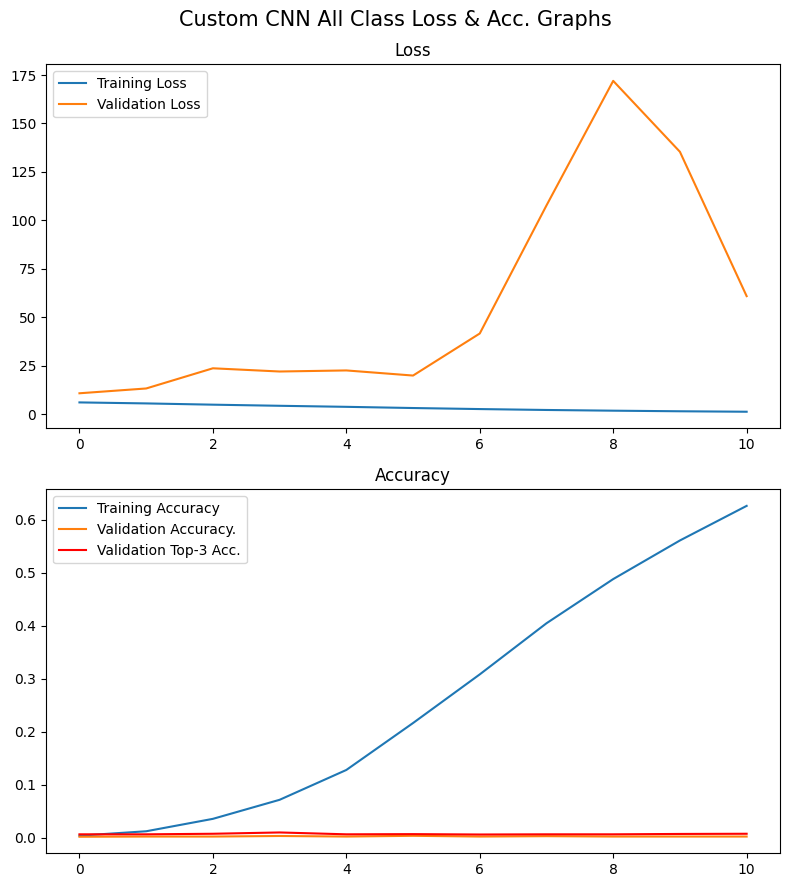

In [28]:
plt.figure(figsize=(8,9))
plt.suptitle("Custom CNN All Class Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [29]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.0028 - loss: 22.0264 - top3_acc: 0.0074
{'acc': 0.0028070176485925913, 'loss': 22.02643585205078, 'top3_acc': 0.0073684211820364}


    ^^overfitting/not learning properly

## Augmentations

In [30]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(0.02, 0.02),
])

model = models.Sequential([

    layers.Input(shape=INPUT_SHAPE),

    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    #removed a block

    # Feature extraction layer (good for t-SNE later)
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
],name="custom_augment")

model.summary()

Model: "custom_augment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 384, 384, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 384, 384, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 192, 192, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 192, 192, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 192, 192, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 96, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 475)            │       122,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,243 (973.61 KB)

 Trainable params: 248,795 (971.86 KB)

 Non-trainable params: 448 (1.75 KB)

### epochs

In [31]:
%%time

epochs = 70

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), ##make sure is true
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_acc',   # Metric to monitor (e.g., validation loss)
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    min_delta=0.001,      # Minimum change to qualify as an improvement
    mode='max',
    verbose=1,            # Log messages when the callback acts
    restore_best_weights=True # Restores the best model weights
)

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds,
    callbacks=[early_stopping])

model.save(f"{drive_dir}/Custom_allclass_aug.keras")

Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 168ms/step - acc: 0.0028 - loss: 6.1335 - top3_acc: 0.0097 - val_acc: 0.0021 - val_loss: 28.7051 - val_top3_acc: 0.0063
Epoch 2/70
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - acc: 0.0059 - loss: 5.8822 - top3_acc: 0.0188 - val_acc: 0.0021 - val_loss: 39.3896 - val_top3_acc: 0.0063
Epoch 3/70
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - acc: 0.0178 - loss: 5.4269 - top3_acc: 0.0458 - val_acc: 0.0021 - val_loss: 146.7739 - val_top3_acc: 0.0063
Epoch 4/70
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - acc: 0.0432 - loss: 4.8283 - top3_acc: 0.1081 - val_acc: 0.0021 - val_loss: 210.9189 - val_top3_acc: 0.0070
Epoch 5/70
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - acc: 0.0761 - loss: 4.3397 - top3_acc: 0.1788 - val_acc: 0.0021 - val_loss: 36.3830 - val_top3_acc: 0.0105
Epoch 6/70
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - acc: 0.1107 - loss: 3.9757 - top3_acc: 0.2490 - val_acc: 0.0025 - val_loss: 105.2197 - val_top3_acc: 0.0081
Epoch 7/70
112/112 ━━━━━

In [32]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"{drive_dir}/Custom_allclass_aug_lossacc.csv")

### Visualization

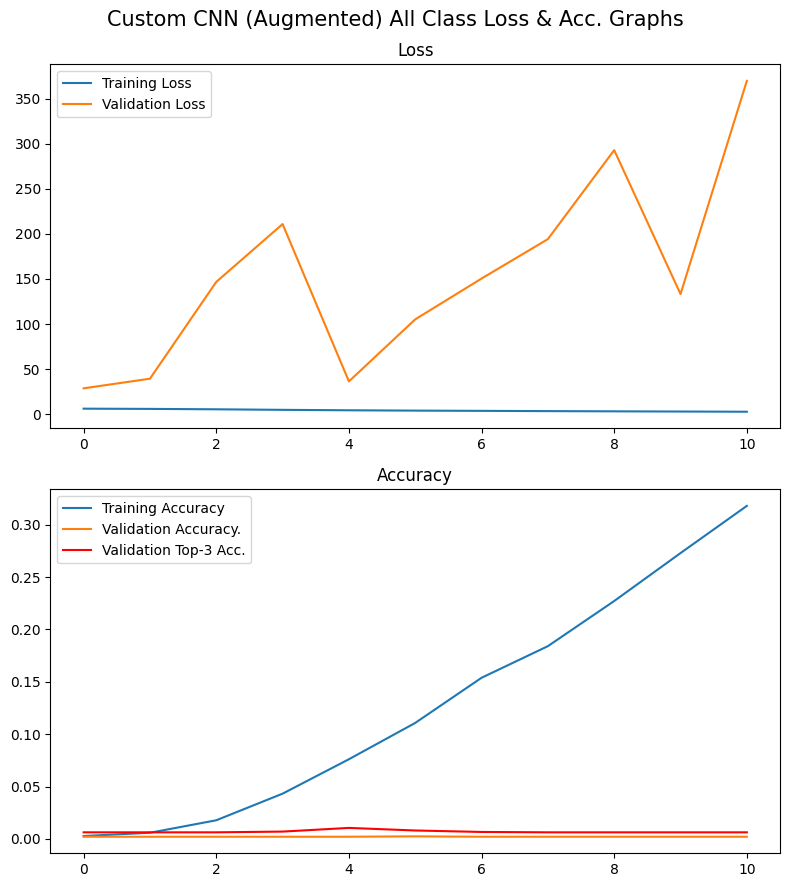

In [33]:
plt.figure(figsize=(8,9))
plt.suptitle("Custom CNN (Augmented) All Class Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [34]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.0021 - loss: 28.7124 - top3_acc: 0.0063    
{'acc': 0.0021052630618214607, 'loss': 28.712352752685547, 'top3_acc': 0.0063157896511256695}


# XAI

- GRAD-CAM
- LIME(?)
- Feature Extraction + UMAP

In [ ]:
model = load_model("/content/MobileNetV2_allclass.keras")

In [ ]:
model.summary()

Model: "mobilenet_allclass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 475)            │       608,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,083,411 (15.58 MB)

 Trainable params: 608,475 (2.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,216,952 (4.64 MB)

In [ ]:
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

features = feature_extractor.predict(test_ds)

45/45 ━━━━━━━━━━━━━━━━━━━━ 494s 10s/step


In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
proj = tsne.fit_transform(features)

In [ ]:
#get labels

labels = np.concatenate([y for x, y in test_ds], axis=0)

# convert from one-hot if necessary
#labels = np.argmax(labels, axis=1)

### t-sne

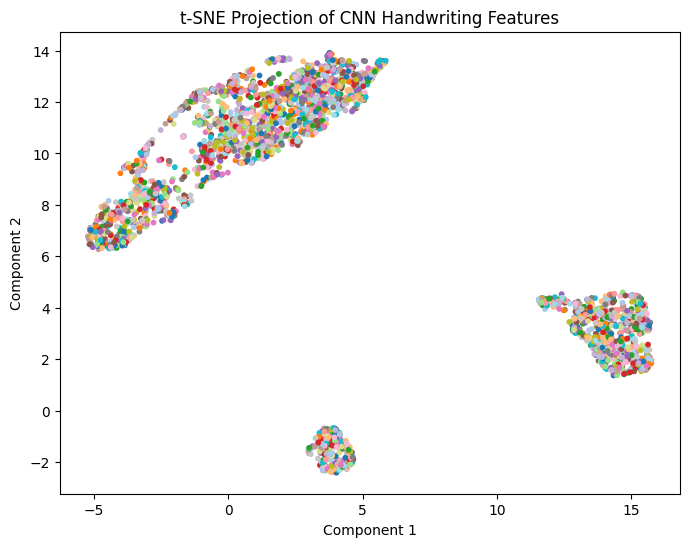

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    proj[:,0],
    proj[:,1],
    c=labels,
    cmap="tab20",
    s=10
)

plt.title("t-SNE Projection of CNN Handwriting Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

    subset

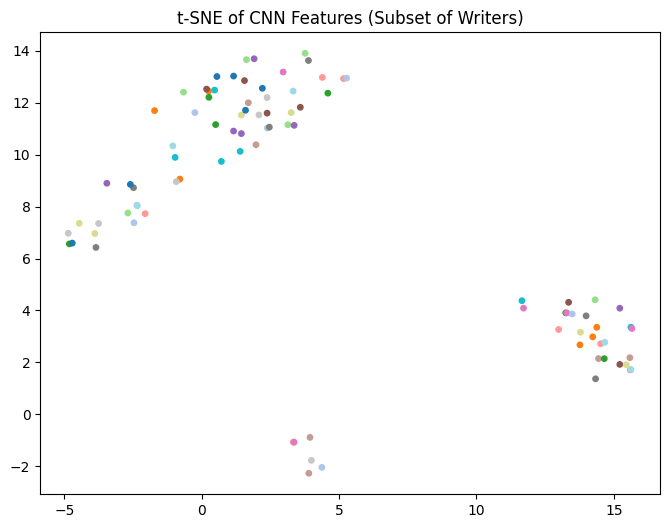

In [ ]:
subset_classes = np.unique(labels)[:15]   # first 15 writers

mask = np.isin(labels, subset_classes)

proj_subset = proj[mask]
labels_subset = labels[mask]

plt.figure(figsize=(8,6))

plt.scatter(
    proj_subset[:,0],
    proj_subset[:,1],
    c=labels_subset,
    cmap="tab20",
    s=15
)

plt.title("t-SNE of CNN Features (Subset of Writers)")
plt.show()

### umap

In [ ]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    random_state=410
)

proj = reducer.fit_transform(features)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


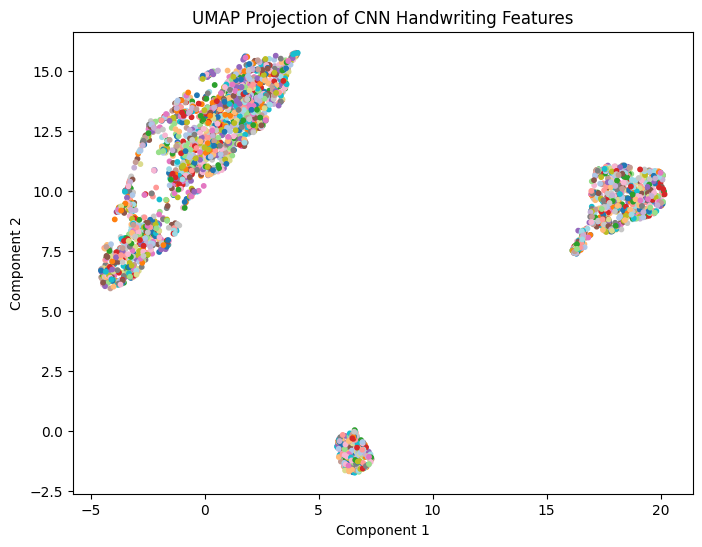

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    proj[:,0],
    proj[:,1],
    c=labels,
    cmap="tab20",
    s=10
)

plt.title("UMAP Projection of CNN Handwriting Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

In [ ]:
subset_classes = np.unique(labels)[:15]   # first 15 writers

mask = np.isin(labels, subset_classes)

proj_subset = proj[mask]
labels_subset = labels[mask]

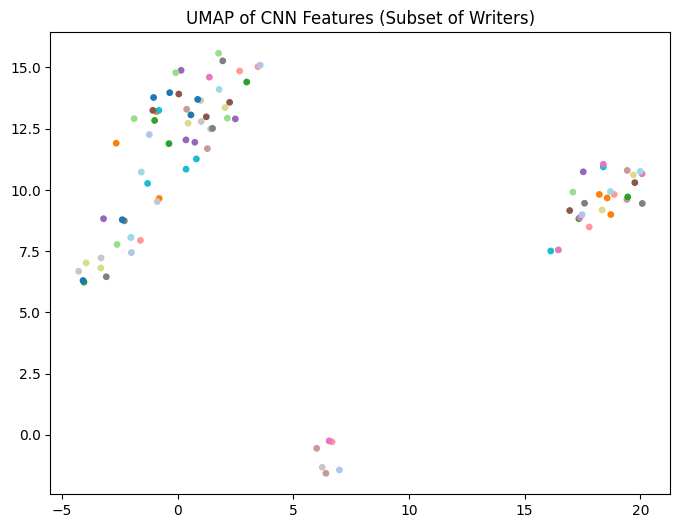

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    proj_subset[:,0],
    proj_subset[:,1],
    c=labels_subset,
    cmap="tab20",
    s=15
)

plt.title("UMAP of CNN Features (Subset of Writers)")
plt.show()

#### By mean

In [ ]:
unique_writers = np.unique(labels)

mean_embeddings = []
writer_ids = []

for writer in unique_writers:

    writer_features = features[labels == writer]

    mean_embedding = writer_features.mean(axis=0)

    mean_embeddings.append(mean_embedding)
    writer_ids.append(writer)

mean_embeddings = np.array(mean_embeddings)

In [ ]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    random_state=410
)

proj = reducer.fit_transform(mean_embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


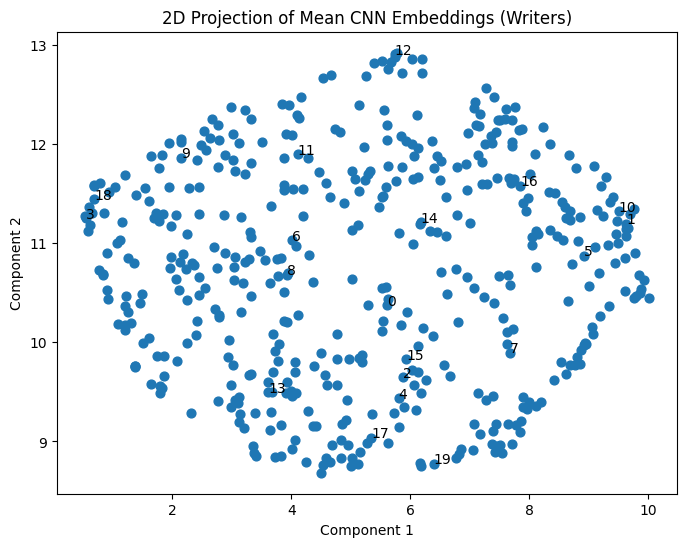

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    proj[:,0],
    proj[:,1],
    #c=writer_ids,
    #cmap="tab20",
    s=40
)

plt.title("2D Projection of Mean CNN Embeddings (Writers)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

for i in range(20):
    plt.text(proj[i,0], proj[i,1], str(writer_ids[i]), fontsize=10)

plt.show()

## 90 Class

In [ ]:
model90 = load_model("/content/MobileNetV2_highres2.keras")
model90.summary()

Model: "mobilenet_highres2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 14, 14, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,856 (9.93 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 230,582 (900.71 KB)

In [ ]:
! unzip "/content/Handwriting_Images_90sorted.zip"

In [ ]:
reload_data2.stratify_split_alt("/content/Handwriting_Images")

Found 1350 files belonging to 90 classes.
Found 540 files belonging to 90 classes.
Found 540 files belonging to 90 classes.


In [ ]:
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(
    "/content/Handwriting_Images",(442,442),64)

Found 1350 files belonging to 90 classes.
Found 540 files belonging to 90 classes.
Found 540 files belonging to 90 classes.


In [ ]:
feature_extractor = tf.keras.Model(
    inputs=model90.input,
    outputs=model90.layers[-3].output
)

features = feature_extractor.predict(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 146s 13s/step


In [ ]:
labels = np.concatenate([y for x, y in test_ds], axis=0)

In [ ]:
!pip uninstall -y sympy
!pip install sympy==1.12

Found existing installation: sympy 1.12
Uninstalling sympy-1.12:
  Successfully uninstalled sympy-1.12
  Using cached sympy-1.12-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.12-py3-none-any.whl (5.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cpu requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


In [ ]:
import umap

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


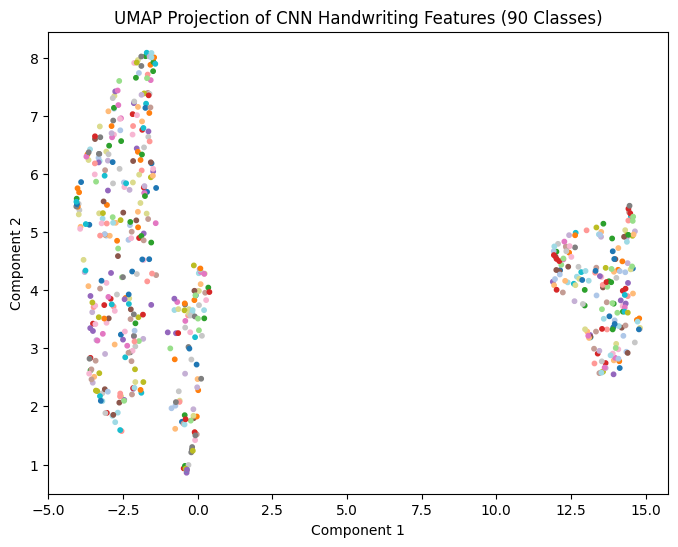

In [ ]:
#import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    random_state=410
)

proj = reducer.fit_transform(features)

plt.figure(figsize=(8,6))

plt.scatter(
    proj[:,0],
    proj[:,1],
    c=labels,
    cmap="tab20",
    s=10
)

plt.title("UMAP Projection of CNN Handwriting Features (90 Classes)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

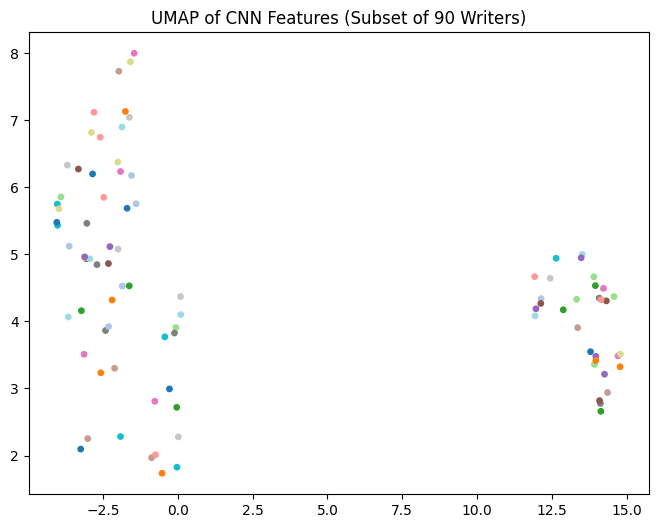

In [ ]:
subset_classes = np.unique(labels)[:15]   # first 15 writers

mask = np.isin(labels, subset_classes)

proj_subset = proj[mask]
labels_subset = labels[mask]


plt.figure(figsize=(8,6))

plt.scatter(
    proj_subset[:,0],
    proj_subset[:,1],
    c=labels_subset,
    cmap="tab20",
    s=15
)

plt.title("UMAP of CNN Features (Subset of 90 Writers)")
plt.show()